### Step 1 — Setup & Imports

In [35]:
!pip install "numpy<2"

In [36]:
import sklearn
print(sklearn.__version__)

1.6.0


In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

In [38]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

from sklearn.metrics import root_mean_squared_error

### Step 2 — MLflow Tracking Setup
Connects MLflow to a local SQLite database (mlflow.db) and creates an experiment called nyc-taxi-experiment.

In [39]:
import mlflow

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("nyc-taxi-experiment")

<Experiment: artifact_location='/workspaces/TravelTimeOptimisation_MLOps/02-ExperimentTracking/mlruns/1', creation_time=1772541828979, experiment_id='1', last_update_time=1772541828979, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}>

### Step 3 — Load & Explore Data
Reads the January 2025 green taxi parquet file directly from a URL.

In [40]:
df = pd.read_parquet('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet')
df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,2,2025-01-01 00:03:01,2025-01-01 00:17:12,N,1.0,75,235,1.0,5.93,24.70,...,0.5,6.80,0.00,NaN,1.0,34.00,1.0,1.0,0.00,0.0
1,2,2025-01-01 00:19:59,2025-01-01 00:25:52,N,1.0,166,75,1.0,1.32,8.60,...,0.5,0.00,0.00,NaN,1.0,11.10,2.0,1.0,0.00,0.0
2,2,2025-01-01 00:05:29,2025-01-01 00:07:21,N,5.0,171,73,1.0,0.41,25.55,...,0.0,0.00,0.00,NaN,1.0,26.55,2.0,2.0,0.00,0.0
3,2,2025-01-01 00:52:24,2025-01-01 01:07:52,N,1.0,74,223,1.0,4.12,21.20,...,0.5,6.13,6.94,NaN,1.0,36.77,1.0,1.0,0.00,0.0
4,2,2025-01-01 00:25:05,2025-01-01 01:01:10,N,1.0,66,158,1.0,4.71,33.80,...,0.5,7.81,0.00,NaN,1.0,46.86,1.0,1.0,2.75,0.0


### Step 4 — Feature Engineering: Create Target Variable
Calculates duration_mins = dropoff time − pickup time, converted to minutes. This is the column you're trying to predict.

In [41]:
df ['duration_mins'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime

Converting duration to minutes

In [42]:
df.duration_mins = df.duration_mins.apply(lambda td: td.total_seconds() / 60)

### Step 5 — Exploratory Analysis
Uses .describe() with custom percentiles (95th, 98th, 99th) to understand the distribution of trip durations.

In [43]:
df.duration_mins.describe()

count    48326.000000
mean        19.955195
std         93.924039
min          0.000000
25%          7.200000
50%         11.250000
75%         16.983333
max       1439.650000
Name: duration_mins, dtype: float64

In [44]:
df.duration_mins.describe(percentiles = [0.95, 0.98, 0.99])

count    48326.000000
mean        19.955195
std         93.924039
min          0.000000
50%         11.250000
95%         32.366667
98%         44.983333
99%         61.991667
max       1439.650000
Name: duration_mins, dtype: float64

### Step 6 — Outlier Filtering
Keeps only trips between 1 and 60 minutes — removes impossibly short/long rides. About 92–95% of data usually survives this filter.

In [45]:
((df.duration_mins >= 1) & (df.duration_mins <= 60)).mean()

0.9582212473616687

In [46]:
#df = ((df.duration_mins >= 1) & (df.duration_mins <= 60))
df = df[(df.duration_mins >= 1) & (df.duration_mins <= 60)]


### Step 7 — Feature Selection (Quick Prototype)
Selects PULocationID, DOLocationID (pickup/dropoff zones) and trip_distance as features. Encodes them using DictVectorizer and trains a quick Linear Regression as a baseline — trains and evaluates on the same training data (not yet split).

In [47]:
categorical = ['PULocationID', 'DOLocationID']
numerical = ['trip_distance']

In [48]:
df[categorical]

,PULocationID,DOLocationID
0,75,235
1,166,75
2,171,73
3,74,223
4,66,158
...,...,...
48321,179,132
48322,166,75
48323,41,42
48324,75,43


In [49]:
train_dicts = df[categorical + numerical].to_dict(orient='records')

dv = DictVectorizer()
X_train = dv.fit_transform(train_dicts)

target = 'duration_mins'
y_train = df[target].values

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_train)

root_mean_squared_error(y_train, y_pred)

8.528512168315896

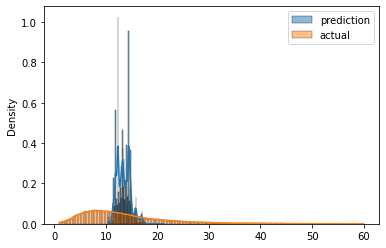

In [50]:
sns.histplot(y_pred, label='prediction', kde=True, stat='density', alpha=0.5)
sns.histplot(y_train, label='actual', kde=True, stat='density', alpha=0.5)

plt.legend()

### Step 8 — Proper Train/Validation Split
Refactors into a read_dataframe() function. Loads January as training data and February as validation data — a realistic time-based split.

In [51]:
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)

        df.lpep_dropoff_datetime = pd.to_datetime(df.lpep_dropoff_datetime)
        df.lpep_pickup_datetime = pd.to_datetime(df.lpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.lpep_dropoff_datetime - df.lpep_pickup_datetime
    df.duration = df.duration.apply(lambda td: td.total_seconds() / 60)

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    df[categorical] = df[categorical].astype(str)
    
    return df

Training and Validation:

In [52]:
df_train = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet')
df_val = read_dataframe('https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet')

In [53]:
len(df_train), len(df_val)

(46307, 44218)

### Step 9 — Feature Engineering (Enhanced)
Creates a combined PU_DO feature by concatenating pickup and dropoff location IDs (e.g., "75_82"). This captures the route pair as a single category, which is more powerful than two separate columns. Also includes trip_type.

In [54]:
df_train['PU_DO'] = df_train['PULocationID'] + '_' + df_train['DOLocationID']
df_val['PU_DO'] = df_val['PULocationID'] + '_' + df_val['DOLocationID']

In [55]:
df_train['trip_type'] = df_train['trip_type'].astype(str)

### Step 10 — DictVectorizer Fit/Transform
Fits the vectorizer on training data only (fit_transform), then applies it to validation (transform only) — this is the correct pattern to prevent data leakage.

In [56]:
categorical = ['PU_DO', 'trip_type'] #'PULocationID', 'DOLocationID']
numerical = ['trip_distance']

dv = DictVectorizer()

train_dicts = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dicts)

val_dicts = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [57]:
target = 'duration'
y_train = df_train[target].values
y_val = df_val[target].values

### Step 11 — Model Comparison: Linear Regression, Lasso, Ridge
All three are trained and evaluated using RMSE on the validation set. The comment in the notebook notes Lasso gave the best RMSE.

Linear Regression:

In [58]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.154305820280958

Lasso:

In [59]:
ls = Lasso(0.1)
ls.fit(X_train, y_train)


y_pred = ls.predict(X_val)

root_mean_squared_error(y_val, y_pred)

9.03424026620296

Ridge:

In [60]:
ls = Ridge(0.1)
ls.fit(X_train, y_train)


y_pred = ls.predict(X_val)

root_mean_squared_error(y_val, y_pred)

6.142132445649105

### Step 12 — Save Best Model (Pickle)
Saves the (DictVectorizer, Lasso) tuple as models/lin_reg.bin using pickle.

In [61]:
#Ridge regressor gives the best rmse value
import os
os.makedirs('models', exist_ok=True)

with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, ls), f_out)

### Step 13 — MLflow Experiment Logging
Wraps a Lasso run in mlflow.start_run(), logging: developer tag, data paths, alpha parameter, and RMSE metric.

In [62]:
with mlflow.start_run():

    mlflow.set_tag("developer", "kirthika")

    mlflow.log_param("train-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet")
    mlflow.log_param("valid-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

### Step 14 — XGBoost + Hyperopt Tuning
Converts data to XGBoost's DMatrix format. Defines an objective function that trains XGBoost with given params, logs everything to MLflow, and returns the RMSE as the loss. Defines a search_space for Hyperopt to explore (max_depth, learning_rate, regularisation terms). Runs 50 trials using tpe.suggest (Bayesian optimisation).

In [63]:
import xgboost as xgb

from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [64]:
train = xgb.DMatrix(X_train, label=y_train)
valid = xgb.DMatrix(X_val, label=y_val)

In [65]:
import sklearn
print(sklearn.__version__)  # you said 1.6.0

# verify the fix works
from sklearn.metrics import root_mean_squared_error
print(root_mean_squared_error(y_val, y_pred))  # should give ~5.x

1.6.0
9.03424026620296


In [66]:
def objective(params):
    with mlflow.start_run():
        mlflow.set_tag("model", "xgboost")
        mlflow.set_experiment("xgboost-hyperopt-tuning")
        mlflow.log_params(params)
        booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )
        y_pred = booster.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

    return {'loss': rmse, 'status': STATUS_OK}

In [68]:
search_space = {
    'max_depth': scope.int(hp.quniform('max_depth', 4, 100, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:linear',
    'seed': 42
}

best_result = fmin(
    fn=objective,
    space=search_space,
    algo=tpe.suggest,
    max_evals=20,
    trials=Trials()
)


  0%|                                                                                                                                                                                                 | 0/20 [00:00<?, ?trial/s, best loss=?]

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:11:58] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:7.33926                                                                                                                                                                                                                  
[1]	validation-rmse:6.41913                                                                                                                                                                                                                  
[2]	validation-rmse:5.97619                                                                                                                                                                                                                  
[3]	validation-rmse:5.76244                                                                                                                                                                                                                  
[4]	validation-rmse:5.66788                     

[68]	validation-rmse:5.58262                                                                                                                                                                                                                 
[69]	validation-rmse:5.58272                                                                                                                                                                                                                 
[70]	validation-rmse:5.58494                                                                                                                                                                                                                 
[71]	validation-rmse:5.58564                                                                                                                                                                                                                 
[72]	validation-rmse:5.58671                    

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:12:21] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



...

[68]	validation-rmse:5.55113                                                                                                                                                                                                                 
[69]	validation-rmse:5.55039                                                                                                                                                                                                                 
[70]	validation-rmse:5.55043                                                                                                                                                                                                                 
[71]	validation-rmse:5.54915                                                                                                                                                                                                                 
[72]	validation-rmse:5.54915                    

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:22:28] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)



[0]	validation-rmse:8.48676                                                                                                                                                                                                                  
[1]	validation-rmse:7.96826                                                                                                                                                                                                                  
[2]	validation-rmse:7.53097                                                                                                                                                                                                                  
[3]	validation-rmse:7.16495                                                                                                                                                                                                                  
[4]	validation-rmse:6.86050                     

[68]	validation-rmse:5.54794                                                                                                                                                                                                                 
[69]	validation-rmse:5.54616                                                                                                                                                                                                                 
[70]	validation-rmse:5.54609                                                                                                                                                                                                                 
[71]	validation-rmse:5.54636                                                                                                                                                                                                                 
[72]	validation-rmse:5.54596                    

[136]	validation-rmse:5.54402                                                                                                                                                                                                                
[137]	validation-rmse:5.54425                                                                                                                                                                                                                
[138]	validation-rmse:5.54415                                                                                                                                                                                                                
[139]	validation-rmse:5.54425                                                                                                                                                                                                                
[140]	validation-rmse:5.54446                   

### Step 15 — Best Model Rerun with Autologging
Takes the best hyperparameters found, enables mlflow.xgboost.autolog(), and retrains — this auto-captures all parameters, metrics, and the model artifact.

In [69]:
params = {
'learning_rate' : 0.2528037473043481,
'max_depth' : 5,
'min_child_weight' : 5.1810101322810915,
'objective' : 'reg:linear',
'reg_alpha' : 0.03263457245161076,
'reg_lambda': 0.04365512556253237,
'seed' : 42
}

mlflow.xgboost.autolog()

booster = xgb.train(
            params=params,
            dtrain=train,
            num_boost_round=1000,
            evals=[(valid, 'validation')],
            early_stopping_rounds=50
        )

2026/04/23 11:25:03 INFO mlflow.utils.autologging_utils: Created MLflow autologging run with ID 'f58de5607a3e41ef84ff70c15c6ecdea', which will track hyperparameters, performance metrics, model artifacts, and lineage information for the current xgboost workflow


[0]	validation-rmse:7.84337
[1]	validation-rmse:7.01899
[2]	validation-rmse:6.51211
[3]	validation-rmse:6.20772
[4]	validation-rmse:6.00776


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:25:06] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[5]	validation-rmse:5.88517
[6]	validation-rmse:5.80441
[7]	validation-rmse:5.75003
[8]	validation-rmse:5.71344
[9]	validation-rmse:5.69572
[10]	validation-rmse:5.68032
[11]	validation-rmse:5.66770
[12]	validation-rmse:5.65845
[13]	validation-rmse:5.65265
[14]	validation-rmse:5.64907
[15]	validation-rmse:5.64607
[16]	validation-rmse:5.64327
[17]	validation-rmse:5.63765
[18]	validation-rmse:5.63369
[19]	validation-rmse:5.63060
[20]	validation-rmse:5.62915
[21]	validation-rmse:5.62633
[22]	validation-rmse:5.62296
[23]	validation-rmse:5.62104
[24]	validation-rmse:5.61913
[25]	validation-rmse:5.61648
[26]	validation-rmse:5.61325
[27]	validation-rmse:5.60873
[28]	validation-rmse:5.60571
[29]	validation-rmse:5.60511
[30]	validation-rmse:5.60194
[31]	validation-rmse:5.60006
[32]	validation-rmse:5.59814
[33]	validation-rmse:5.59653
[34]	validation-rmse:5.59457
[35]	validation-rmse:5.59350
[36]	validation-rmse:5.58713
[37]	validation-rmse:5.58538
[38]	validation-rmse:5.58341
[39]	validation-rms

[282]	validation-rmse:5.40950
[283]	validation-rmse:5.40936
[284]	validation-rmse:5.40923
[285]	validation-rmse:5.40915
[286]	validation-rmse:5.40845
[287]	validation-rmse:5.40851
[288]	validation-rmse:5.40883
[289]	validation-rmse:5.40905
[290]	validation-rmse:5.40907
[291]	validation-rmse:5.40891
[292]	validation-rmse:5.40875
[293]	validation-rmse:5.40859
[294]	validation-rmse:5.40849
[295]	validation-rmse:5.40848
[296]	validation-rmse:5.40840
[297]	validation-rmse:5.40830
[298]	validation-rmse:5.40811
[299]	validation-rmse:5.40805
[300]	validation-rmse:5.40795
[301]	validation-rmse:5.40779
[302]	validation-rmse:5.40768
[303]	validation-rmse:5.40775
[304]	validation-rmse:5.40764
[305]	validation-rmse:5.40748
[306]	validation-rmse:5.40729
[307]	validation-rmse:5.40712
[308]	validation-rmse:5.40723
[309]	validation-rmse:5.40706
[310]	validation-rmse:5.40695
[311]	validation-rmse:5.40662
[312]	validation-rmse:5.40636
[313]	validation-rmse:5.40589
[314]	validation-rmse:5.40574
[315]	vali

[556]	validation-rmse:5.37099
[557]	validation-rmse:5.37044
[558]	validation-rmse:5.37034
[559]	validation-rmse:5.37010
[560]	validation-rmse:5.36938
[561]	validation-rmse:5.36947
[562]	validation-rmse:5.36962
[563]	validation-rmse:5.36942
[564]	validation-rmse:5.36940
[565]	validation-rmse:5.36942
[566]	validation-rmse:5.36953
[567]	validation-rmse:5.36944
[568]	validation-rmse:5.36945
[569]	validation-rmse:5.36953
[570]	validation-rmse:5.36842
[571]	validation-rmse:5.36805
[572]	validation-rmse:5.36795
[573]	validation-rmse:5.36786
[574]	validation-rmse:5.36784
[575]	validation-rmse:5.36814
[576]	validation-rmse:5.36800
[577]	validation-rmse:5.36784
[578]	validation-rmse:5.36737
[579]	validation-rmse:5.36719
[580]	validation-rmse:5.36719
[581]	validation-rmse:5.36723
[582]	validation-rmse:5.36717
[583]	validation-rmse:5.36716
[584]	validation-rmse:5.36719
[585]	validation-rmse:5.36655
[586]	validation-rmse:5.36665
[587]	validation-rmse:5.36668
[588]	validation-rmse:5.36678
[589]	vali

[830]	validation-rmse:5.34450
[831]	validation-rmse:5.34474
[832]	validation-rmse:5.34491
[833]	validation-rmse:5.34486
[834]	validation-rmse:5.34489
[835]	validation-rmse:5.34489
[836]	validation-rmse:5.34453
[837]	validation-rmse:5.34447
[838]	validation-rmse:5.34444
[839]	validation-rmse:5.34444
[840]	validation-rmse:5.34439
[841]	validation-rmse:5.34442
[842]	validation-rmse:5.34442
[843]	validation-rmse:5.34443
[844]	validation-rmse:5.34438
[845]	validation-rmse:5.34422
[846]	validation-rmse:5.34431
[847]	validation-rmse:5.34435
[848]	validation-rmse:5.34438
[849]	validation-rmse:5.34426
[850]	validation-rmse:5.34424
[851]	validation-rmse:5.34404
[852]	validation-rmse:5.34386
[853]	validation-rmse:5.34396
[854]	validation-rmse:5.34403
[855]	validation-rmse:5.34405
[856]	validation-rmse:5.34380
[857]	validation-rmse:5.34381
[858]	validation-rmse:5.34383
[859]	validation-rmse:5.34381
[860]	validation-rmse:5.34373
[861]	validation-rmse:5.34360
[862]	validation-rmse:5.34368
[863]	vali

2026/04/23 11:25:30 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/04/23 11:25:30 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 11:25:31 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:25:31] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/04/23 11:25:46 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmptimgl80w/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/04/23 11:25:46 WARNING mlflow.models.mod

Saving the model by logging - Way 1:

In [70]:
with mlflow.start_run():

    mlflow.set_tag("developer", "kirthika")

    mlflow.log_param("train-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-01.parquet")
    mlflow.log_param("valid-data-path", "https://d37ci6vzurychx.cloudfront.net/trip-data/green_tripdata_2025-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha)
    lr = Lasso(alpha)
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")

Saving the model by logging - Way 2:

In [71]:
with mlflow.start_run():
    params = {
    'learning_rate' : 0.2528037473043481,
    'max_depth' : 5,
    'min_child_weight' : 5.1810101322810915,
    'objective' : 'reg:linear',
    'reg_alpha' : 0.03263457245161076,
    'reg_lambda': 0.04365512556253237,
    'seed' : 42
    }
    mlflow.log_params(params)


    booster = xgb.train(
                params=params,
                dtrain=train,
                num_boost_round=1000,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.xgboost.log_model(booster, name="models_mlflow")

/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:26:58] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[0]	validation-rmse:7.84337
[1]	validation-rmse:7.01899
[2]	validation-rmse:6.51211
[3]	validation-rmse:6.20772
[4]	validation-rmse:6.00776
[5]	validation-rmse:5.88517
[6]	validation-rmse:5.80441
[7]	validation-rmse:5.75003
[8]	validation-rmse:5.71344
[9]	validation-rmse:5.69572
[10]	validation-rmse:5.68032
[11]	validation-rmse:5.66770
[12]	validation-rmse:5.65845
[13]	validation-rmse:5.65265
[14]	validation-rmse:5.64907
[15]	validation-rmse:5.64607
[16]	validation-rmse:5.64327
[17]	validation-rmse:5.63765
[18]	validation-rmse:5.63369
[19]	validation-rmse:5.63060
[20]	validation-rmse:5.62915
[21]	validation-rmse:5.62633
[22]	validation-rmse:5.62296
[23]	validation-rmse:5.62104
[24]	validation-rmse:5.61913
[25]	validation-rmse:5.61648
[26]	validation-rmse:5.61325
[27]	validation-rmse:5.60873
[28]	validation-rmse:5.60571
[29]	validation-rmse:5.60511
[30]	validation-rmse:5.60194
[31]	validation-rmse:5.60006
[32]	validation-rmse:5.59814
[33]	validation-rmse:5.59653
[34]	validation-rmse:5.5

[277]	validation-rmse:5.41115
[278]	validation-rmse:5.41025
[279]	validation-rmse:5.41005
[280]	validation-rmse:5.40987
[281]	validation-rmse:5.40960
[282]	validation-rmse:5.40950
[283]	validation-rmse:5.40936
[284]	validation-rmse:5.40923
[285]	validation-rmse:5.40915
[286]	validation-rmse:5.40845
[287]	validation-rmse:5.40851
[288]	validation-rmse:5.40883
[289]	validation-rmse:5.40905
[290]	validation-rmse:5.40907
[291]	validation-rmse:5.40891
[292]	validation-rmse:5.40875
[293]	validation-rmse:5.40859
[294]	validation-rmse:5.40849
[295]	validation-rmse:5.40848
[296]	validation-rmse:5.40840
[297]	validation-rmse:5.40830
[298]	validation-rmse:5.40811
[299]	validation-rmse:5.40805
[300]	validation-rmse:5.40795
[301]	validation-rmse:5.40779
[302]	validation-rmse:5.40768
[303]	validation-rmse:5.40775
[304]	validation-rmse:5.40764
[305]	validation-rmse:5.40748
[306]	validation-rmse:5.40729
[307]	validation-rmse:5.40712
[308]	validation-rmse:5.40723
[309]	validation-rmse:5.40706
[310]	vali

[551]	validation-rmse:5.37170
[552]	validation-rmse:5.37173
[553]	validation-rmse:5.37131
[554]	validation-rmse:5.37129
[555]	validation-rmse:5.37100
[556]	validation-rmse:5.37099
[557]	validation-rmse:5.37044
[558]	validation-rmse:5.37034
[559]	validation-rmse:5.37010
[560]	validation-rmse:5.36938
[561]	validation-rmse:5.36947
[562]	validation-rmse:5.36962
[563]	validation-rmse:5.36942
[564]	validation-rmse:5.36940
[565]	validation-rmse:5.36942
[566]	validation-rmse:5.36953
[567]	validation-rmse:5.36944
[568]	validation-rmse:5.36945
[569]	validation-rmse:5.36953
[570]	validation-rmse:5.36842
[571]	validation-rmse:5.36805
[572]	validation-rmse:5.36795
[573]	validation-rmse:5.36786
[574]	validation-rmse:5.36784
[575]	validation-rmse:5.36814
[576]	validation-rmse:5.36800
[577]	validation-rmse:5.36784
[578]	validation-rmse:5.36737
[579]	validation-rmse:5.36719
[580]	validation-rmse:5.36719
[581]	validation-rmse:5.36723
[582]	validation-rmse:5.36717
[583]	validation-rmse:5.36716
[584]	vali

[825]	validation-rmse:5.34581
[826]	validation-rmse:5.34587
[827]	validation-rmse:5.34524
[828]	validation-rmse:5.34505
[829]	validation-rmse:5.34495
[830]	validation-rmse:5.34450
[831]	validation-rmse:5.34474
[832]	validation-rmse:5.34491
[833]	validation-rmse:5.34486
[834]	validation-rmse:5.34489
[835]	validation-rmse:5.34489
[836]	validation-rmse:5.34453
[837]	validation-rmse:5.34447
[838]	validation-rmse:5.34444
[839]	validation-rmse:5.34444
[840]	validation-rmse:5.34439
[841]	validation-rmse:5.34442
[842]	validation-rmse:5.34442
[843]	validation-rmse:5.34443
[844]	validation-rmse:5.34438
[845]	validation-rmse:5.34422
[846]	validation-rmse:5.34431
[847]	validation-rmse:5.34435
[848]	validation-rmse:5.34438
[849]	validation-rmse:5.34426
[850]	validation-rmse:5.34424
[851]	validation-rmse:5.34404
[852]	validation-rmse:5.34386
[853]	validation-rmse:5.34396
[854]	validation-rmse:5.34403
[855]	validation-rmse:5.34405
[856]	validation-rmse:5.34380
[857]	validation-rmse:5.34381
[858]	vali

2026/04/23 11:27:21 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/04/23 11:27:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 11:27:22 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:27:22] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/04/23 11:27:30 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpy3xplmo1/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/04/23 11:27:30 WARNING mlflow.models.mod

Saving preprocessor - DictVectorizer:

In [72]:
with open("models/preprocessor.b", "wb") as f_out:
    pickle.dump(dv, f_out)

In [73]:
with mlflow.start_run():
    params = {
    'learning_rate' : 0.2528037473043481,
    'max_depth' : 5,
    'min_child_weight' : 5.1810101322810915,
    'objective' : 'reg:linear',
    'reg_alpha' : 0.03263457245161076,
    'reg_lambda': 0.04365512556253237,
    'seed' : 42
    }
    mlflow.log_params(params)


    booster = xgb.train(
                params=params,
                dtrain=train,
                num_boost_round=1000,
                evals=[(valid, 'validation')],
                early_stopping_rounds=50
            )
    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)
    
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")
    mlflow.xgboost.log_model(booster, name="models_mlflow")

[0]	validation-rmse:7.84337
[1]	validation-rmse:7.01899
[2]	validation-rmse:6.51211
[3]	validation-rmse:6.20772
[4]	validation-rmse:6.00776
[5]	validation-rmse:5.88517
[6]	validation-rmse:5.80441


/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:28:01] WARNING: /workspace/src/objective/regression_obj.cu:227: reg:linear is now deprecated in favor of reg:squarederror.
  warnings.warn(smsg, UserWarning)


[7]	validation-rmse:5.75003
[8]	validation-rmse:5.71344
[9]	validation-rmse:5.69572
[10]	validation-rmse:5.68032
[11]	validation-rmse:5.66770
[12]	validation-rmse:5.65845
[13]	validation-rmse:5.65265
[14]	validation-rmse:5.64907
[15]	validation-rmse:5.64607
[16]	validation-rmse:5.64327
[17]	validation-rmse:5.63765
[18]	validation-rmse:5.63369
[19]	validation-rmse:5.63060
[20]	validation-rmse:5.62915
[21]	validation-rmse:5.62633
[22]	validation-rmse:5.62296
[23]	validation-rmse:5.62104
[24]	validation-rmse:5.61913
[25]	validation-rmse:5.61648
[26]	validation-rmse:5.61325
[27]	validation-rmse:5.60873
[28]	validation-rmse:5.60571
[29]	validation-rmse:5.60511
[30]	validation-rmse:5.60194
[31]	validation-rmse:5.60006
[32]	validation-rmse:5.59814
[33]	validation-rmse:5.59653
[34]	validation-rmse:5.59457
[35]	validation-rmse:5.59350
[36]	validation-rmse:5.58713
[37]	validation-rmse:5.58538
[38]	validation-rmse:5.58341
[39]	validation-rmse:5.58223
[40]	validation-rmse:5.58094
[41]	validation-r

[284]	validation-rmse:5.40923
[285]	validation-rmse:5.40915
[286]	validation-rmse:5.40845
[287]	validation-rmse:5.40851
[288]	validation-rmse:5.40883
[289]	validation-rmse:5.40905
[290]	validation-rmse:5.40907
[291]	validation-rmse:5.40891
[292]	validation-rmse:5.40875
[293]	validation-rmse:5.40859
[294]	validation-rmse:5.40849
[295]	validation-rmse:5.40848
[296]	validation-rmse:5.40840
[297]	validation-rmse:5.40830
[298]	validation-rmse:5.40811
[299]	validation-rmse:5.40805
[300]	validation-rmse:5.40795
[301]	validation-rmse:5.40779
[302]	validation-rmse:5.40768
[303]	validation-rmse:5.40775
[304]	validation-rmse:5.40764
[305]	validation-rmse:5.40748
[306]	validation-rmse:5.40729
[307]	validation-rmse:5.40712
[308]	validation-rmse:5.40723
[309]	validation-rmse:5.40706
[310]	validation-rmse:5.40695
[311]	validation-rmse:5.40662
[312]	validation-rmse:5.40636
[313]	validation-rmse:5.40589
[314]	validation-rmse:5.40574
[315]	validation-rmse:5.40539
[316]	validation-rmse:5.40506
[317]	vali

[558]	validation-rmse:5.37034
[559]	validation-rmse:5.37010
[560]	validation-rmse:5.36938
[561]	validation-rmse:5.36947
[562]	validation-rmse:5.36962
[563]	validation-rmse:5.36942
[564]	validation-rmse:5.36940
[565]	validation-rmse:5.36942
[566]	validation-rmse:5.36953
[567]	validation-rmse:5.36944
[568]	validation-rmse:5.36945
[569]	validation-rmse:5.36953
[570]	validation-rmse:5.36842
[571]	validation-rmse:5.36805
[572]	validation-rmse:5.36795
[573]	validation-rmse:5.36786
[574]	validation-rmse:5.36784
[575]	validation-rmse:5.36814
[576]	validation-rmse:5.36800
[577]	validation-rmse:5.36784
[578]	validation-rmse:5.36737
[579]	validation-rmse:5.36719
[580]	validation-rmse:5.36719
[581]	validation-rmse:5.36723
[582]	validation-rmse:5.36717
[583]	validation-rmse:5.36716
[584]	validation-rmse:5.36719
[585]	validation-rmse:5.36655
[586]	validation-rmse:5.36665
[587]	validation-rmse:5.36668
[588]	validation-rmse:5.36678
[589]	validation-rmse:5.36688
[590]	validation-rmse:5.36694
[591]	vali

[832]	validation-rmse:5.34491
[833]	validation-rmse:5.34486
[834]	validation-rmse:5.34489
[835]	validation-rmse:5.34489
[836]	validation-rmse:5.34453
[837]	validation-rmse:5.34447
[838]	validation-rmse:5.34444
[839]	validation-rmse:5.34444
[840]	validation-rmse:5.34439
[841]	validation-rmse:5.34442
[842]	validation-rmse:5.34442
[843]	validation-rmse:5.34443
[844]	validation-rmse:5.34438
[845]	validation-rmse:5.34422
[846]	validation-rmse:5.34431
[847]	validation-rmse:5.34435
[848]	validation-rmse:5.34438
[849]	validation-rmse:5.34426
[850]	validation-rmse:5.34424
[851]	validation-rmse:5.34404
[852]	validation-rmse:5.34386
[853]	validation-rmse:5.34396
[854]	validation-rmse:5.34403
[855]	validation-rmse:5.34405
[856]	validation-rmse:5.34380
[857]	validation-rmse:5.34381
[858]	validation-rmse:5.34383
[859]	validation-rmse:5.34381
[860]	validation-rmse:5.34373
[861]	validation-rmse:5.34360
[862]	validation-rmse:5.34368
[863]	validation-rmse:5.34367
[864]	validation-rmse:5.34383
[865]	vali

2026/04/23 11:28:24 WARNING mlflow.xgboost: Failed to infer model signature: could not sample data to infer model signature: please ensure that autologging is enabled before constructing the dataset.
2026/04/23 11:28:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/23 11:28:24 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "/home/codespace/anaconda3/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [11:28:24] WARNING: /workspace/src/c_api/c_api.cc:1374: Saving model in the UBJSON format as default.  You can use file extension: `json`, `ubj` or `deprecated` to choose between formats."
2026/04/23 11:28:30 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /tmp/tmpiq8gcajw/model, flavor: xgboost). Fall back to return ['xgboost==2.1.4']. Set logging level to DEBUG to see the full traceback. 
2026/04/23 11:28:30 WARNING mlflow.models.mod